#### Importing Libraries, Cleaning & Feature Engineering

In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv('data_set/dating_app_behavior_encoded.csv')

print(f"Dataset loaded successfully with shape: {df.shape}")

Dataset loaded successfully with shape: (50000, 80)


In [71]:
X = df.drop(columns=['match_outcomes', 'interest_tags'], errors='ignore')
y = df['match_outcomes']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Number of unique classes to predict: {len(np.unique(y))}")

Training features shape: (40000, 78)
Testing features shape: (10000, 78)
Number of unique classes to predict: 10


In [72]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


In [74]:
# Initialize the Multi-Layer Perceptron Classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # Two hidden layers with 128 and 64 neurons respectively
    activation='relu',             # Rectified Linear Unit activation function
    solver='adam',                 # Standard efficient gradient-based optimizer
    max_iter=500,                  # Maximum number of epochs
    random_state=42,               # Reproducible results
    verbose=True                   # Shows training progress/loss per iteration
)

# Train the model
print("Starting MLP training...")
mlp.fit(X_train_scaled, y_train)
print("MLP training completed!")

Starting MLP training...
Iteration 1, loss = 2.33357249
Iteration 2, loss = 2.29652926
Iteration 3, loss = 2.28265477
Iteration 4, loss = 2.27023539
Iteration 5, loss = 2.25768668
Iteration 6, loss = 2.24553309
Iteration 7, loss = 2.23123570
Iteration 8, loss = 2.21669808
Iteration 9, loss = 2.20222673
Iteration 10, loss = 2.18830256
Iteration 11, loss = 2.17351945
Iteration 12, loss = 2.16006698
Iteration 13, loss = 2.14712731
Iteration 14, loss = 2.13393529
Iteration 15, loss = 2.12084547
Iteration 16, loss = 2.11117843
Iteration 17, loss = 2.09903061
Iteration 18, loss = 2.08907903
Iteration 19, loss = 2.08087883
Iteration 20, loss = 2.07138586
Iteration 21, loss = 2.06170521
Iteration 22, loss = 2.05349780
Iteration 23, loss = 2.04600920
Iteration 24, loss = 2.03910439
Iteration 25, loss = 2.03163797
Iteration 26, loss = 2.02552887
Iteration 27, loss = 2.01926758
Iteration 28, loss = 2.01247707
Iteration 29, loss = 2.00558561
Iteration 30, loss = 1.99973912
Iteration 31, loss = 1.9

Overall Model Accuracy: 0.1010

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.10      0.10      0.10      1010
           1       0.11      0.11      0.11      1005
           2       0.10      0.09      0.10      1004
           3       0.11      0.15      0.12       984
           4       0.09      0.09      0.09       992
           5       0.13      0.09      0.11      1016
           6       0.10      0.13      0.12       998
           7       0.09      0.07      0.08       997
           8       0.09      0.11      0.10      1022
           9       0.10      0.07      0.08       972

    accuracy                           0.10     10000
   macro avg       0.10      0.10      0.10     10000
weighted avg       0.10      0.10      0.10     10000



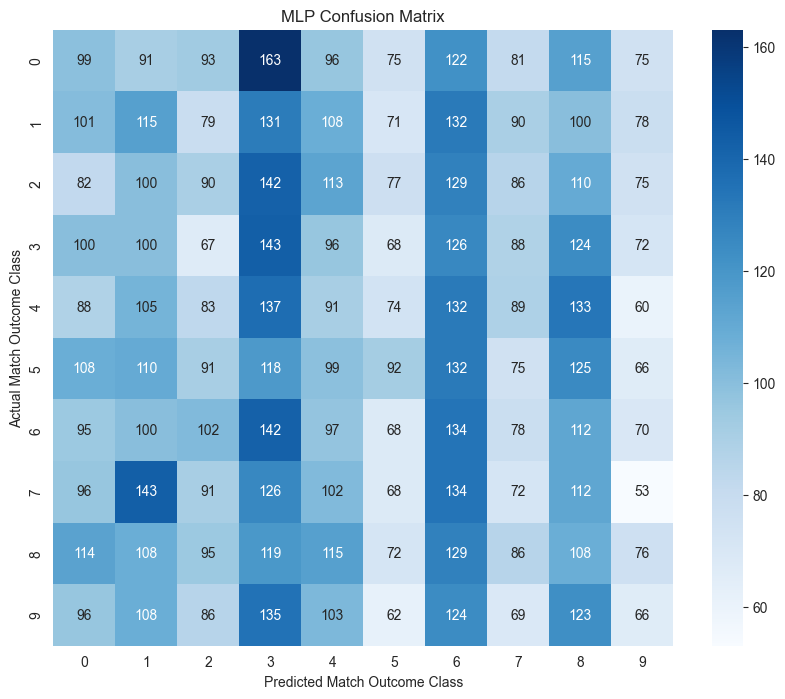

In [75]:
# Predict outcomes on the test set
y_pred = mlp.predict(X_test_scaled)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy:.4f}\n")

# Display the classification report (Precision, Recall, F1-Score per class)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted Match Outcome Class')
plt.ylabel('Actual Match Outcome Class')
plt.show()